In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, accuracy_score
import numpy as np
import itertools
import random
from tensorflow import keras
from tensorflow.keras import layers, regularizers, optimizers, callbacks
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
import matplotlib.pyplot as plt



/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
2026-06-19 00:34:23.884428: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
 # ── 1. Load dataset ───────────────────────────────────────────────────────────
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)   # ← change to your file path

# ── 2. Separate features and target ──────────────────────────────────────────
X = df.drop(columns=['sii'])        # ← change 'target' to your label column
y = df['sii'].values

In [3]:
# ── 3. Split: Train 70% | Validation 15% | Test 15% ──────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y          # keeps class balance in each split
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,     # 50% of the 30% → 15% of total each
    random_state=42,
    stratify=y_temp
)
"""over_dic={1:1300,2:1000,
    3:300}
under_dic = {0:4000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
under = RandomUnderSampler(sampling_strategy=under_dic)
X_train, y_train = over.fit_resample(X_train, y_train)
X_train, y_train = under.fit_resample(X_train, y_train)"""


print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Train:      5866 samples
Validation: 1257 samples
Test:       1258 samples


In [4]:
def build_nn(hidden_layers, activation, reg_type, reg_penalty, lr, momentum, optimizer_name, n_classes, dropout_rate=0.3):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train_scaled.shape[1],)))
   
    for units in hidden_layers:
        # Dense → BatchNorm → Activation → Dropout
        model.add(layers.Dense(units, kernel_regularizer=reg_type(reg_penalty)))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(n_classes, activation='softmax', #output layer? can we try different functions?
                           kernel_regularizer=reg_type(reg_penalty)))

    if optimizer_name == 'sgd':   # ← now properly refers to the parameter
        opt = optimizers.SGD(learning_rate=lr, momentum=momentum)
    else:
        opt = optimizers.Adam(learning_rate=lr)

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=opt, metrics=['accuracy'])
    return model

In [5]:

def plot_learning_curves(history, figure_label="Learning curves of the neural network"):
    """
    history: oggetto restituito da model.fit()
    figure_label: testo della didascalia sotto il plot
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Loss ─────────────────────────────────────────────────────────────────
    ax1.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # ── Accuracy ──────────────────────────────────────────────────────────────
    ax2.plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='lower right')

    # ── Didascalia sotto ──────────────────────────────────────────────────────
    fig.text(0.5, -0.02, figure_label, ha='center', fontsize=13)

    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

In [6]:
# ── 2. Parameter grid ─────────────────────────────────────────────────────────
"""param_grid = {
    'hidden_layers': [[4, 8], [32, 64, 32], [64, 128, 64]],
    'activation':    ['sigmoid', 'relu'],
    'optimizer':     ['adam', 'sgd'],
    'lr':            [0.1, 0.05, 0.01, 0.005, 0.001],
    'reg_type':      [regularizers.l1, regularizers.l2],
    'reg_penalty':   [0.1, 0.05, 0.01, 0.005, 0.001],
    'momentum':      [0.9, 0.5, 0.1],   # ignored when optimizer=adam
    'epochs':        [100, 500, 1000],
    'batch_size':    [128, 256, 1024, 2048],
}"""
param_grid = {
    'hidden_layers': [#[4, 8],
        [32, 64, 32], [64, 128, 64]],
    'activation':    ['relu'],
    'optimizer':     ['adam'],
    'lr':            [0.0001, 0.001, 5e-4, 1e-4],
    'reg_type':      [regularizers.l1, regularizers.l2],
    'reg_penalty':   [0.001, 1e-4, 1e-3, 0.0],
    'momentum':      [0.9, 0.5, 0.1],          # usato solo se optimizer=sgd
    'epochs':        [200, 500, 1000],
    'batch_size':    [64, 128, 256, 1024, 2048],
    #'dropout_rate':  [0.2, 0.3, 0.5],  # ← NUOVO parametro
    'dropout_rate': [0.3, 0.1, 0.2]}

N_ITER   = 5    # number of random combos to try
N_FOLDS  = 3      # k for cross-validation
RANDOM_STATE = 42
N_CLASSES = len(np.unique(y_train))  # → 4 in your case

random.seed(RANDOM_STATE)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(enumerate(class_weights_array))

In [14]:
# ── 3. Random search with k-fold CV ──────────────────────────────────────────


# Sample N_ITER random combinations
keys   = list(param_grid.keys())
combos = []
seen   = set()
while len(combos) < N_ITER:
    combo = {k: random.choice(param_grid[k]) for k in keys}
    key   = str(combo)
    if key not in seen:
        seen.add(key)
        combos.append(combo)

kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

best_score  = -np.inf
best_params = None
results     = []



for i, params in enumerate(combos):
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        X_f_train, X_f_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_f_train, y_f_val = y_train[train_idx],        y_train[val_idx]

        # Use adam lr if optimizer is adam, else sgd lr
        lr = params['lr'] if params['optimizer'] == 'sgd' else params['lr']

        model = build_nn(
            hidden_layers=params['hidden_layers'],
            activation=params['activation'],
            reg_type=params['reg_type'],
            reg_penalty=params['reg_penalty'],
            lr=lr,
            momentum=params['momentum'] if params['optimizer'] == 'sgd' else 0.0,
            optimizer_name=params['optimizer'],   # ← add this
            n_classes=N_CLASSES,
            dropout_rate=params['dropout_rate']
        )


        # Light early stopping during search to save time
        es = callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                     min_delta=1e-4, verbose=0)

        model.fit(X_f_train, y_f_train,
                  epochs=params['epochs'],
                  batch_size=params['batch_size'],
                  validation_data=(X_f_val, y_f_val),
                  #class_weight=class_weight,
                  callbacks=[es],
                  verbose=0)

        """_, acc = model.evaluate(X_f_val, y_f_val, verbose=0)
        fold_scores.append(acc)"""

        y_f_pred = np.argmax(model.predict(X_f_val, verbose=0), axis=1)
        score = f1_score(y_f_val, y_f_pred, average='macro', zero_division=0)
        fold_scores.append(score)

    mean_score = np.mean(fold_scores)
    results.append({'params': params, 'score': mean_score})
    print(f"[{i+1:2d}/{N_ITER}] score={mean_score:.4f} | {params}")

    if mean_score > best_score:
        best_score  = mean_score
        best_params = params

print("\nBest CV score:", best_score)
print("Best params:  ", best_params)

[ 1/5] score=0.2074 | {'hidden_layers': [32, 64, 32], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.001, 'reg_type': <class 'keras.src.regularizers.regularizers.L1'>, 'reg_penalty': 0.0001, 'momentum': 0.1, 'epochs': 200, 'batch_size': 2048, 'dropout_rate': 0.3}
[ 2/5] score=0.2363 | {'hidden_layers': [64, 128, 64], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.0001, 'reg_type': <class 'keras.src.regularizers.regularizers.L1'>, 'reg_penalty': 0.0001, 'momentum': 0.1, 'epochs': 1000, 'batch_size': 64, 'dropout_rate': 0.2}
[ 3/5] score=0.2163 | {'hidden_layers': [32, 64, 32], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.0001, 'reg_type': <class 'keras.src.regularizers.regularizers.L2'>, 'reg_penalty': 0.001, 'momentum': 0.9, 'epochs': 1000, 'batch_size': 1024, 'dropout_rate': 0.1}
[ 4/5] score=0.2642 | {'hidden_layers': [64, 128, 64], 'activation': 'relu', 'optimizer': 'adam', 'lr': 0.0005, 'reg_type': <class 'keras.src.regularizers.regularizers.L1'>, 'reg_penalty': 0.001

Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2137 - loss: 2.5088 - val_accuracy: 0.0955 - val_loss: 2.1420 - learning_rate: 1.0000e-04
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2073 - loss: 2.3690 - val_accuracy: 0.1472 - val_loss: 2.1167 - learning_rate: 1.0000e-04
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2216 - loss: 2.3796 - val_accuracy: 0.1997 - val_loss: 2.0995 - learning_rate: 1.0000e-04
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2271 - loss: 2.3508 - val_accuracy: 0.2482 - val_loss: 2.0818 - learning_rate: 1.0000e-04
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2390 - loss: 2.2603 - val_accuracy: 0.2792 - val_loss: 2.0679 - learning_rate: 1.0000e-04
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2486 - loss: 2.2692 - val_accuracy: 0.3071 - val_loss: 2.0589 - learning_rate: 1.0000e-04
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

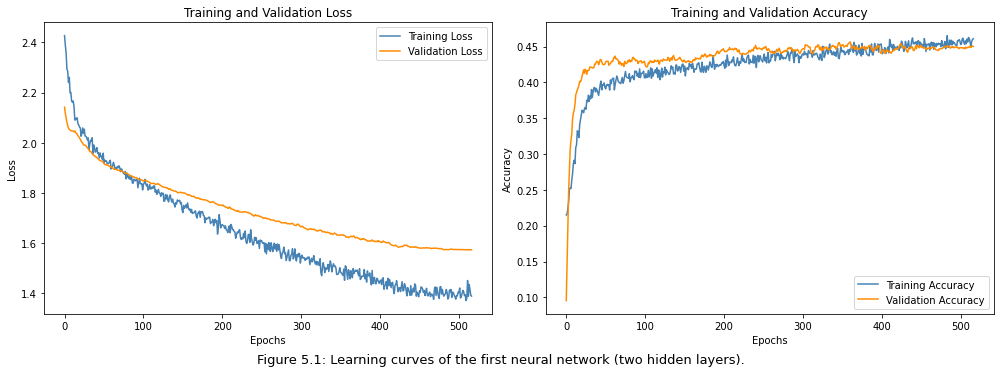

In [13]:
 # ── 4. Final retrain with best params + proper early stopping ─────────────────
"""if best_params['optimizer'] == 'adam':
    opt = optimizers.Adam(learning_rate=best_params['lr'])
else:
    opt = optimizers.SGD(learning_rate=best_params['lr'],
                         momentum=best_params['momentum'])

final_model = build_nn(
    hidden_layers=best_params['hidden_layers'],
    activation=best_params['activation'],
    reg_type=best_params['reg_type'],
    reg_penalty=best_params['reg_penalty'],
    lr=best_params['lr'],
    momentum=0.1,#best_params['momentum'] if best_params['optimizer'] == 'sgd' else 0.0,
    optimizer_name=best_params['optimizer'],  # ← add this
    n_classes=N_CLASSES,  
    dropout_rate=best_params['dropout_rate']
)"""
opt = optimizers.Adam(learning_rate=0.0001)
final_model = build_nn(
    hidden_layers=[32, 64, 32],
    activation='relu',
    reg_type=regularizers.l1,
    reg_penalty=0.001,
    lr=0.0001, #PREVENT OVERFITTING
    momentum=0.1,
    optimizer_name='adam',  # ← add this
    n_classes=N_CLASSES,
    dropout_rate=0.1
)

es = callbacks.EarlyStopping(monitor='val_loss', patience=30, #PREVENT OVERFITTING
                              min_delta=1e-4, verbose=True)
mc = callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss',
                                save_best_only=True)
rlr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

history = final_model.fit(
    X_train_scaled, y_train,
    epochs=1000,
    #batch_size=best_params['batch_size'],
    batch_size = 256,
    shuffle=True,
    class_weight=class_weight,
    validation_data=(X_val_scaled, y_val),
    callbacks=[es, mc, rlr]
)

plot_learning_curves(
    history,
    figure_label="Figure 5.1: Learning curves of the first neural network (two hidden layers)."
)

In [14]:

# ── 5. Final evaluation on test set ──────────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score, f1_score

best_model_loaded = keras.models.load_model('best_model.keras')
y_pred = np.argmax(best_model_loaded.predict(X_test_scaled), axis=1)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 macro:', f1_score(y_test, y_pred, average='macro'))
print('F1 per class:', f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.4395866454689984
F1 macro: 0.2777514528595304
F1 per class: [0.61807989 0.2109375  0.25168539 0.03030303]
              precision    recall  f1-score   support

         0.0       0.79      0.51      0.62       870
         1.0       0.19      0.23      0.21       235
         2.0       0.18      0.40      0.25       141
         3.0       0.02      0.17      0.03        12

    accuracy                           0.44      1258
   macro avg       0.30      0.33      0.28      1258
weighted avg       0.60      0.44      0.50      1258



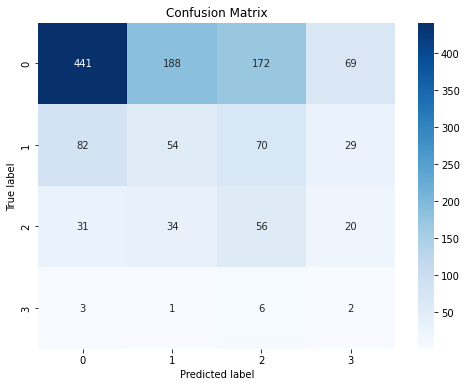

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


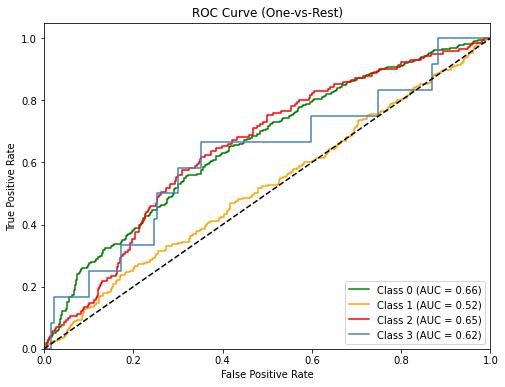

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_score = best_model_loaded.predict(X_test_scaled)
n_classes = len(np.unique(y_test))

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 🎨 colori richiesti
custom_colors = ['green', 'orange', 'red', 'steelblue']

plt.figure(figsize=(8, 6))

for i, color in zip(range(n_classes), custom_colors):
    plt.plot(
        fpr[i], tpr[i],
        color=color,
        label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.show()